# Задание

## Описание задания

В домашнем задании вам нужно решить задачу классификации наличия болезни сердца у пациентов наиболее эффективно. Данные для обучения моделей необходимо загрузить по ссылке.

Целевая переменная - наличие болезни сердца (HeartDisease). Она принимает значения 0 или 1 в зависимости от отсутствия или наличия болезни.

Подробное описание признаков дано в файле README; разбираться в медицинских деталях необязательно, важно понять, как построить и улучшить модель.

**Этапы работы:**

1. Загрузите данные.
2. Подготовьте датасет к обучению моделей.
3. Разделите выборку на обучающее и тестовое подмножества.
4. Обучите классификатор KNN с параметрами по умолчанию и зафиксируйте качество модели.
5. Подберите оптимальное количество соседей и тип весов для алгоритма KNN.
6. Сравните работу алгоритмов GridSearchCV и RandomizedSearchCV.
7. Сравните KNN с другой моделью.
8. Реализуйте Байесовскую оптимизацию.
9. Сделайте выводы о работе алгоритма.


# Инструкция к выполнению


### Шаг 1. Загрузка данных

Получите данные и загрузите их в рабочую среду.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('heart.csv')

display(df.head())
display(df.shape)
display(df.columns)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


(918, 12)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

### Шаг 2. Подготовка датасета к обучению

Подготовьте датасет к обучению моделей:

● Обработайте пропущенные значения и дубликаты.
● Категориальные переменные переведите в цифровые значения. Можно использовать pd.get_dummies, preprocessing.LabelEncoder. Старайтесь не использовать для этой задачи циклы.
● При необходимости выполните масштабирование признаков (например, StandardScaler для KNN) и объясните, как оно повлияло на качество модели.


In [2]:
df.info()
display(df.isna().sum())
display(df.duplicated().sum())
display(df['HeartDisease'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

np.int64(0)

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [3]:
# смотрю уникальные значения текстовых признаков
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    print(col, '-', df[col].unique())

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# бинарные признаки и порядковый ST_Slope перевожу напрямую без циклов
X['Sex'] = X['Sex'].map({'M': 1, 'F': 0})
X['ExerciseAngina'] = X['ExerciseAngina'].map({'Y': 1, 'N': 0})
X['ST_Slope'] = X['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})

# номинальные признаки - через one-hot кодирование
X = pd.get_dummies(X, columns=['ChestPainType', 'RestingECG'])

display(X.head())
display(X.shape)

Sex - <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType - <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG - <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina - <StringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope - <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,2,False,True,False,False,False,True,False
1,49,0,160,180,0,156,0,1.0,1,False,False,True,False,False,True,False
2,37,1,130,283,0,98,0,0.0,2,False,True,False,False,False,False,True
3,48,0,138,214,0,108,1,1.5,1,True,False,False,False,False,True,False
4,54,1,150,195,0,122,0,0.0,2,False,False,True,False,False,True,False


(918, 16)

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# сравниваю KNN с масштабированием и без него
# scaler внутри Pipeline, чтобы не подглядывать в валидационные фолды
knn_raw = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
knn_scaled = cross_val_score(Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]), X, y, cv=cv)

print('Без масштабирования:', round(knn_raw.mean(), 4), '+/-', round(knn_raw.std(), 4))
print('С масштабированием:', round(knn_scaled.mean(), 4), '+/-', round(knn_scaled.std(), 4))
print('Прирост точности:', round(knn_scaled.mean() - knn_raw.mean(), 4))

Без масштабирования: 0.7146 +/- 0.0241
С масштабированием: 0.8464 +/- 0.0169
Прирост точности: 0.1318


### Вывод по шагу 2

Пропусков и дубликатов в данных нет, чистить почти нечего. Категориальные признаки закодировал без циклов: Sex, ExerciseAngina и порядковый ST_Slope перевёл в числа через map, а ChestPainType и RestingECG разложил через pd.get_dummies. Классы почти сбалансированы (508 пациентов с болезнью против 410 здоровых), поэтому балансировка не понадобилась.

Масштабирование для KNN критично: без него точность на кросс-валидации 0.7146, после StandardScaler - 0.8464, прирост 0.13. KNN работает с расстояниями, а признаки живут в разных масштабах (холестерин - сотни, oldpeak - доли), и без масштабирования крупные признаки просто задавливают остальные.

### Шаг 3. Разделение выборки

Разделите данные на обучающую и тестовую выборки, используя train_test_split.

● 80% объектов используйте для обучения, 20% - для теста (test_size=0.2).
● При разделении используйте параметр stratify=y, чтобы сохранить пропорции классов.


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)
print('Доли классов в обучающей выборке:', y_train.value_counts(normalize=True).round(3).to_dict())

# масштабирую по обучающей части, чтобы тестовая не участвовала в расчёте статистик
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Обучающая выборка: (734, 16)
Тестовая выборка: (184, 16)
Доли классов в обучающей выборке: {1: 0.553, 0: 0.447}


### Шаг 4. Базовая модель KNN и кросс-валидация

● Обучите классификатор KNN с параметрами по умолчанию (KNeighborsClassifier).
● Реализуйте кросс-валидацию с помощью функции cross_val_score.
● Зафиксируйте среднее качество, стандартное отклонение метрики и разброс значений по фолдам.
● Сделайте короткий вывод: насколько устойчива модель, есть ли признаки переобучения/недообучения.
● Основная метрика - accuracy. По желанию можно дополнительно считать F1-меру и/или ROC-AUC.


In [6]:
knn = KNeighborsClassifier()

cv_scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='accuracy')

print('Точность по фолдам:', np.round(cv_scores, 4))
print('Средняя точность:', round(cv_scores.mean(), 4))
print('Стандартное отклонение:', round(cv_scores.std(), 4))
print('Разброс по фолдам: от', round(cv_scores.min(), 4), 'до', round(cv_scores.max(), 4))

# точность на обучающей выборке - для проверки переобучения
knn.fit(X_train_sc, y_train)
print('Точность на обучающей выборке:', round(knn.score(X_train_sc, y_train), 4))

def_cv_mean = cv_scores.mean()
def_cv_std = cv_scores.std()

Точность по фолдам: [0.8367 0.7687 0.8231 0.8776 0.8425]
Средняя точность: 0.8297
Стандартное отклонение: 0.0354
Разброс по фолдам: от 0.7687 до 0.8776
Точность на обучающей выборке: 0.876


### Вывод по шагу 4

KNN с параметрами по умолчанию (k=5) даёт на кросс-валидации 0.8297 +/- 0.0354. Разброс по фолдам заметный: от 0.7687 до 0.8776, то есть разница между лучшим и худшим фолдом почти 0.11. На обучающей выборке точность 0.8760 против 0.8297 на валидации - разрыв небольшой, признаков сильного переобучения нет, для KNN такая разница нормальна. Модель в целом устойчивая, но качество хочется поднять подбором гиперпараметров.

### Шаг 5. Подбор гиперпараметров KNN: GridSearchCV и RandomizedSearchCV

Подберите оптимальное количество соседей и тип весов ("uniform" или "distance") на основе cross_val_score.

**GridSearchCV:**

● Задайте сетку гиперпараметров.
● Запустите GridSearchCV с нужной метрикой и числом фолдов.
● Зафиксируйте лучший набор гиперпараметров, значение метрики и время работы.

**RandomizedSearchCV:**

● Задайте распределения для n_neighbors и weights.
● Запустите RandomizedSearchCV с ограничением n_iter.
● Аналогично зафиксируйте лучший набор гиперпараметров, метрику и время работы.

**Сравнение методов.** Сравните результаты GridSearchCV и RandomizedSearchCV:

● Отличаются ли найденные настройки.
● Насколько различается время работы.
● Есть ли существенная разница в качестве.


In [7]:
from sklearn.model_selection import GridSearchCV
import time

param_grid = {'n_neighbors': list(range(1, 31)),
              'weights': ['uniform', 'distance']}

start = time.time()
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_sc, y_train)
grid_time = time.time() - start

grid_best_std = grid.cv_results_['std_test_score'][grid.best_index_]
print('Лучшие параметры:', grid.best_params_)
print('Лучшая точность на кросс-валидации:', round(grid.best_score_, 4))
print('Стандартное отклонение лучшей модели:', round(grid_best_std, 4))
print('Время работы:', round(grid_time, 2), 'с')

Лучшие параметры: {'n_neighbors': 9, 'weights': 'uniform'}
Лучшая точность на кросс-валидации: 0.8379
Стандартное отклонение лучшей модели: 0.0328
Время работы: 3.28 с


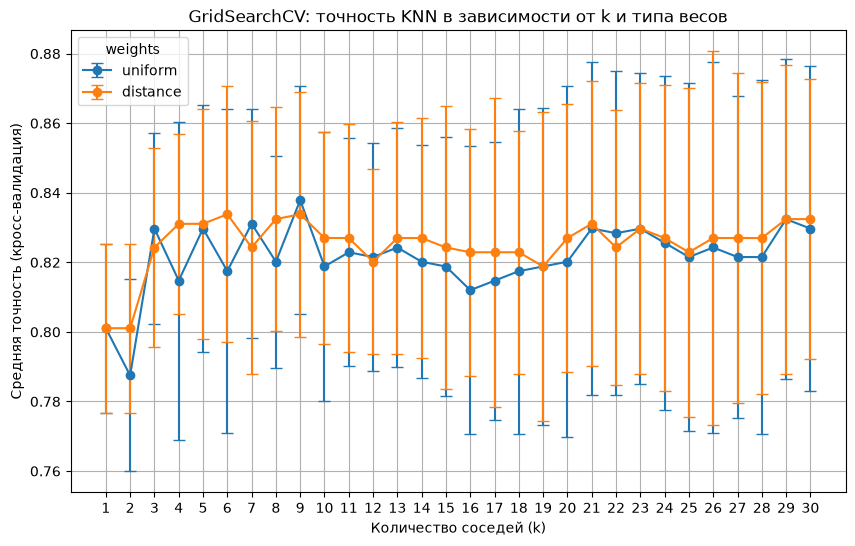

In [8]:
# зависимость точности от числа соседей для обоих типов весов
fig, ax = plt.subplots(figsize=(10, 6))

for w in ['uniform', 'distance']:
    mask = grid.cv_results_['param_weights'] == w
    ks_w = grid.cv_results_['param_n_neighbors'][mask].astype(int)
    means = grid.cv_results_['mean_test_score'][mask]
    stds = grid.cv_results_['std_test_score'][mask]
    order = np.argsort(ks_w)
    ax.errorbar(ks_w[order], means[order], yerr=stds[order], marker='o', capsize=4, label=w)

ax.set_xlabel('Количество соседей (k)')
ax.set_ylabel('Средняя точность (кросс-валидация)')
ax.set_title('GridSearchCV: точность KNN в зависимости от k и типа весов')
ax.set_xticks(range(1, 31))
ax.grid(True)
ax.legend(title='weights')
plt.show()

In [9]:
from sklearn.model_selection import RandomizedSearchCV

start = time.time()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_grid,
                                   n_iter=20, cv=cv, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train_sc, y_train)
rand_time = time.time() - start

rand_best_std = random_search.cv_results_['std_test_score'][random_search.best_index_]
print('Лучшие параметры:', random_search.best_params_)
print('Лучшая точность на кросс-валидации:', round(random_search.best_score_, 4))
print('Стандартное отклонение лучшей модели:', round(rand_best_std, 4))
print('Время работы:', round(rand_time, 3), 'с')

Лучшие параметры: {'weights': 'distance', 'n_neighbors': 9}
Лучшая точность на кросс-валидации: 0.8338
Стандартное отклонение лучшей модели: 0.0352
Время работы: 0.071 с


In [10]:
# свожу результаты обоих методов поиска в таблицу
search_compare = pd.DataFrame({
    'Метод': ['GridSearchCV', 'RandomizedSearchCV'],
    'Лучшие параметры': [str(grid.best_params_), str(random_search.best_params_)],
    'Точность (CV)': [round(grid.best_score_, 4), round(random_search.best_score_, 4)],
    'Время, с': [round(grid_time, 2), round(rand_time, 2)]
})
display(search_compare)

,Метод,Лучшие параметры,Точность (CV),"Время, с"
0,GridSearchCV,"{'n_neighbors': 9, 'weights': 'uniform'}",0.8379,3.28
1,RandomizedSearchCV,"{'weights': 'distance', 'n_neighbors': 9}",0.8338,0.07


### Вывод по шагу 5

GridSearchCV перебрал все 60 комбинаций (30 значений k на 2 типа весов) и нашёл лучшее решение - k=9, weights=uniform с точностью 0.8379, потратив около 3 секунд. RandomizedSearchCV проверил только 20 случайных комбинаций: лучший результат тоже k=9, но weights=distance, точность 0.8338, время - примерно 0.07 секунды.

Оптимальное число соседей совпало, а тип весов разошёлся, хотя качество почти одинаковое, разница всего 0.004. На графике видно, что точность быстро растёт до k=5-10, дальше выходит на плато около 0.82-0.83, а совсем маленькие k=1-2 заметно хуже. Если хочется гарантированный максимум качества - лучше GridSearchCV, если время дороже - RandomizedSearchCV даёт почти то же качество в разы быстрее.

### Шаг 6. Сравнение с другой моделью

● Обучите дополнительную модель на тех же данных.
● Оцените качество этой модели с помощью cross_val_score, используя тот же способ кросс-валидации и тот же тип метрики, что и для KNN.
● Сравните среднюю метрику и разброс метрики по фолдам.
● Сделайте вывод: какая модель выглядит предпочтительнее для данной задачи и почему (качество, устойчивость, интерпретируемость).


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr_cv = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='accuracy')
lr_cv_mean = lr_cv.mean()
lr_cv_std = lr_cv.std()
print('LogisticRegression на CV:', round(lr_cv_mean, 4), '+/-', round(lr_cv_std, 4))
print('KNN (после GridSearchCV) на CV:', round(grid.best_score_, 4), '+/-', round(grid_best_std, 4))

# обучаю обе модели и проверяю на отложенном тесте
best_knn = grid.best_estimator_
best_knn.fit(X_train_sc, y_train)
lr.fit(X_train_sc, y_train)

y_pred_knn = best_knn.predict(X_test_sc)
y_proba_knn = best_knn.predict_proba(X_test_sc)[:, 1]
y_pred_lr = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

test_results = pd.DataFrame({
    'Модель': ['KNN (k=9, uniform)', 'LogisticRegression'],
    'Accuracy': [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_lr)],
    'F1': [f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_lr)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_knn), roc_auc_score(y_test, y_proba_lr)]
})
display(test_results.round(4))

LogisticRegression на CV: 0.8366 +/- 0.0356
KNN (после GridSearchCV) на CV: 0.8379 +/- 0.0328


,Модель,Accuracy,F1,ROC-AUC
0,"KNN (k=9, uniform)",0.8967,0.9073,0.9248
1,LogisticRegression,0.8641,0.8804,0.9002


### Вывод по шагу 6

Логистическая регрессия на кросс-валидации почти догнала тюнингованную KNN: 0.8366 +/- 0.0356 против 0.8379 +/- 0.0328, разброс по фолдам у обеих похожий. Зато на отложенном тесте KNN заметно сильнее: accuracy 0.8967 против 0.8641, ROC-AUC 0.9248 против 0.9002.

По качеству для этой задачи предпочтительнее KNN после тюнинга. Логистическая регрессия интерпретируемее - коэффициенты напрямую показывают вклад каждого признака - и она проще, поэтому подойдёт как запасной вариант, когда важнее объяснить решение модели, а не выжать максимум точности.

### Шаг 7. Байесовская оптимизация гиперпараметров KNN

Воспользуйтесь библиотекой hyperopt для оптимизации гиперпараметров KNN.

● Задайте пространство гиперпараметров с помощью модуля hp.
● Определите целевую функцию:
  ● функция принимает словарь гиперпараметров;
  ● внутри создаёт модель KNN с этими параметрами;
  ● считает cross_val_score с scoring="accuracy";
  ● возвращает отрицательное среднее значение метрики.
● Создайте объект Trials для сохранения истории поиска.
● Вызовите fmin, указав:
  ● целевую функцию;
  ● пространство поиска;
  ● алгоритм tpe.suggest;
  ● максимальное количество оценок (max_evals).
● Сравните результат Байесовской оптимизации с GridSearchCV и RandomizedSearchCV:
  ● какое качество удалось получить;
  ● сколько итераций потребовалось;
  ● совпадает ли найденный оптимум;
  ● в чём преимущество вероятностного подхода (TPE) по сравнению с полным перебором и случайным поиском.


In [12]:
from hyperopt import hp, fmin, tpe, Trials

# пространство поиска: k от 1 до 30, тип весов - один из двух
space = {
    'n_neighbors': hp.quniform('n_neighbors', 1, 30, 1),
    'weights': hp.choice('weights', ['uniform', 'distance'])
}

# целевая функция возвращает отрицательную среднюю точность
def objective(params):
    knn = KNeighborsClassifier(n_neighbors=int(params['n_neighbors']),
                               weights=params['weights'])
    score = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    return -score

trials = Trials()
start = time.time()
best = fmin(fn=objective, space=space, algo=tpe.suggest, trials=trials,
            max_evals=40, rstate=np.random.default_rng(42), show_progressbar=False)
bayes_time = time.time() - start

best_k = int(best['n_neighbors'])
best_w = ['uniform', 'distance'][int(best['weights'])]
print('Лучшие параметры: k =', best_k, ', weights =', best_w)
print('Лучшая точность на CV:', round(-trials.best_trial['result']['loss'], 4))
print('Проверено комбинаций:', len(trials.trials))
print('Время работы:', round(bayes_time, 2), 'с')

# стандартное отклонение модели из TPE считаю отдельно, чтобы сравнить с остальными
tpe_knn = KNeighborsClassifier(n_neighbors=best_k, weights=best_w)
tpe_cv = cross_val_score(tpe_knn, X_train_sc, y_train, cv=cv, scoring='accuracy')
tpe_cv_mean = tpe_cv.mean()
tpe_cv_std = tpe_cv.std()

Лучшие параметры: k = 6 , weights = distance
Лучшая точность на CV: 0.8338
Проверено комбинаций: 40
Время работы: 1.16 с


### Вывод по шагу 7

hyperopt с алгоритмом TPE за 40 итераций вышел на точность 0.8338 (k=6, weights=distance). Качество совпало с RandomizedSearchCV (0.8338) и лишь чуть ниже GridSearchCV (0.8379), при этом комбинаций проверено меньше, чем у полного перебора (60), а время работы - около секунды.

Оптимум по качеству совпал со случайным поиском, хотя по параметрам немного разошёлся (у RandomizedSearchCV лучшим стало k=9, у TPE - k=6, и оба с weights=distance). Преимущество TPE в том, что каждая следующая попытка выбирается не вслепую, а с учётом предыдущих результатов: алгоритм оценивает, где искать дальше - рядом с уже найденным хорошим решением или в малоизученной области. На этой задаче выигрыш не очень заметен, потому что KNN обучается мгновенно, но на дорогих моделях такой подход обычно находит оптимум заметно быстрее случайного поиска и полного перебора.

### Шаг 8. Выводы о работе алгоритма

● Сравните все рассмотренные модели и настройки (базовый KNN, KNN после тюнинга разными методами, альтернативная модель).
● Обсудите, как предобработка данных (кодирование, масштабирование, балансировка) повлияла на качество.
● Укажите, какую модель вы выбрали бы для практического использования и почему (включая метрику и устойчивость качества).
● Кратко свяжите выбор гиперпараметров с переобучением/недообучением (например, малый k в KNN → склонность к переобучению).


In [13]:
# сводная таблица всех моделей
summary = pd.DataFrame({
    'Модель': ['KNN по умолчанию', 'KNN + GridSearchCV', 'KNN + RandomizedSearchCV', 'KNN + TPE', 'LogisticRegression'],
    'Точность (CV)': [def_cv_mean, grid.best_score_, random_search.best_score_, tpe_cv_mean, lr_cv_mean],
    'Стд. отклонение': [def_cv_std, grid_best_std, rand_best_std, tpe_cv_std, lr_cv_std]
})
display(summary.round(4))

,Модель,Точность (CV),Стд. отклонение
0,KNN по умолчанию,0.8297,0.0354
1,KNN + GridSearchCV,0.8379,0.0328
2,KNN + RandomizedSearchCV,0.8338,0.0352
3,KNN + TPE,0.8338,0.0368
4,LogisticRegression,0.8366,0.0356


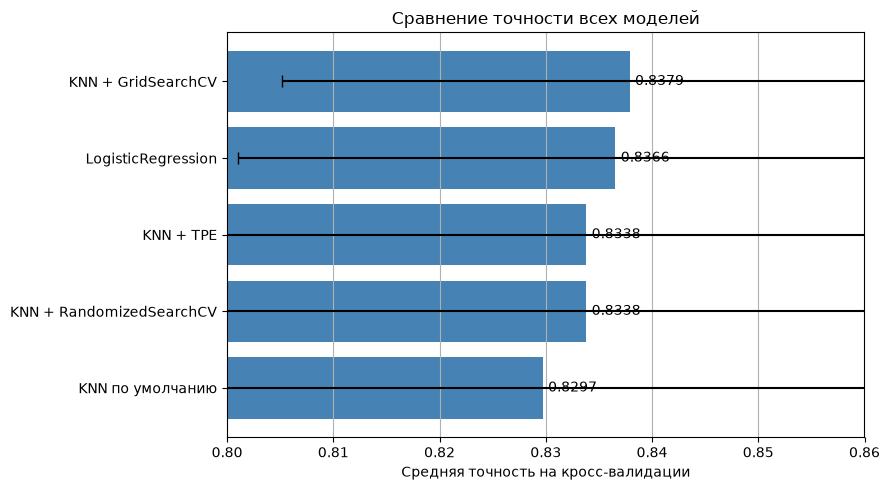

In [14]:
plot_df = summary.sort_values('Точность (CV)')

plt.figure(figsize=(9, 5))
plt.barh(plot_df['Модель'], plot_df['Точность (CV)'], xerr=plot_df['Стд. отклонение'], capsize=4, color='steelblue')
plt.xlabel('Средняя точность на кросс-валидации')
plt.title('Сравнение точности всех моделей')
plt.xlim(0.8, 0.86)
for i, v in enumerate(plot_df['Точность (CV)']):
    plt.text(v + 0.0005, i, str(round(v, 4)), va='center')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Accuracy: 0.8967
F1: 0.9073
ROC-AUC: 0.9248


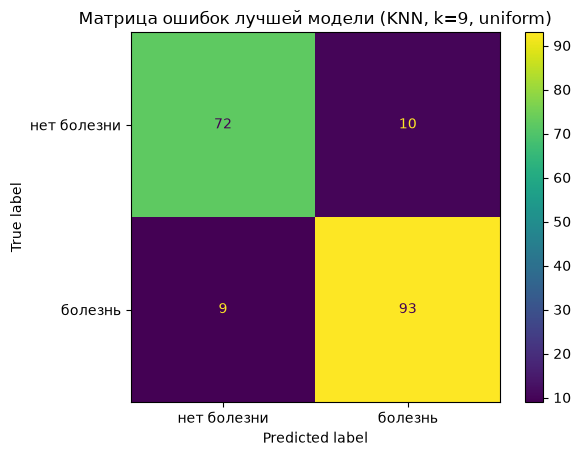

In [16]:
# финальная проверка лучшей модели на тесте
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_knn = KNeighborsClassifier(n_neighbors=9, weights='uniform')
final_knn.fit(X_train_sc, y_train)
y_pred_final = final_knn.predict(X_test_sc)

print('Accuracy:', round(accuracy_score(y_test, y_pred_final), 4))
print('F1:', round(f1_score(y_test, y_pred_final), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, final_knn.predict_proba(X_test_sc)[:, 1]), 4))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['нет болезни', 'болезнь']).plot()
plt.title('Матрица ошибок лучшей модели (KNN, k=9, uniform)')
plt.show()

### Итог:

- Сравнение моделей: базовая KNN дала 0.8297, после подбора гиперпараметров точность выросла до 0.8379 (GridSearchCV, k=9, uniform). RandomizedSearchCV (0.8338) и TPE (0.8338) нашли решения почти такого же качества, но быстрее. Логистическая регрессия на кросс-валидации практически вровень с лучшей KNN (0.8366), но на тесте уступает: 0.8641 против 0.8967.

- Предобработка: пропусков и дубликатов в данных не было; категории закодированы через map и get_dummies; классы почти сбалансированы, балансировка не потребовалась. Самый большой прирост качества дало масштабирование - для KNN точность выросла с 0.7146 до 0.8464, без StandardScaler модель сильно теряет.

- Для практического использования взял бы KNN с k=9 и weights=uniform: точность на кросс-валидации 0.8379 +/- 0.033, на тесте accuracy 0.8967, F1 0.9073, ROC-AUC 0.9248. Модель стабильна и не переобучается. Если в задаче важна интерпретируемость, разумная альтернатива - логистическая регрессия с почти тем же качеством на валидации.

- Связь гиперпараметров с переобучением: маленький k (1-2) строит слишком сложную границу и запоминает отдельные точки - риск переобучения. Слишком большой k, наоборот, слишком сильно сглаживает границу, модель становится проще - растёт смещение и риск недообучения. Оптимум на этих данных лежит в районе 5-10 соседей, что видно по графику из шага 5.